In [1]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "2"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True


In [ ]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
# from DCGAN.encoder import Encoder
# from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.unet import UNet
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
# from DCGAN.encoder import Encoder
# from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.unet import UNet
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [4]:
load_run = None
config_name = 'config.yaml'

In [5]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/31/config.yaml


In [6]:

img_channels = 3
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]
number_of_components = config['models']['number_of_components']

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']
gen_vector_dim = config['models']['gen']['vector_dim']
gen_vectorizer_linear_layer_multipliers = config['models']['gen']['linear_layer_multipliers']
gen_degrees_of_freedom = config['models']['gen']['degrees_of_freedom']

seg_gen_block_depth = config['models']['segmentation_gen']['block_depth']
seg_gen_residual = config['models']['segmentation_gen']['residual']
seg_gen_use_norm = config['models']['segmentation_gen']['use_norm']
seg_gen_cut_connections = config['models']['segmentation_gen']['cut_connections']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_feature_loss_weight = config['training']['enc']['enc_feature_loss_weight']

gen_lr = config['training']['gen']['gen_lr']

seg_gen_lr=  config['training']['segmentation_gen']['seg_gen_lr']
seg_gen_entropy_loss_weight = config['training']['segmentation_gen']['entropy_loss_weight']

n_critic = config['training']['disc']['n_critic']
disc_lr = config['training']['disc']['disc_lr']
disc_gp_loss_weight = config['training']['disc']['disc_gp_loss_weight']
disc_drift_loss_weight = config['training']['disc']['disc_drift_loss_weight']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

rec_gen = os.path.join(index_folder,'rec_gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')
seg_gen_path = os.path.join(index_folder,'seg_gen.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [7]:
rec_gen = UNet(channels=channels,
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=img_channels * number_of_components,
                cut_connections=0,
                use_norm=gen_use_norm).to(device)

seg_gen = UNet(channels=channels,
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=number_of_components,
                cut_connections=seg_gen_cut_connections,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)



if load_run is not None:
    rec_gen.load_state_dict(torch.load(rec_gen))
    seg_gen.load_state_dict(torch.load(seg_gen_path))
    disc.load_state_dict(torch.load(disc_path))





rec_gen_optim = Adam(rec_gen.parameters(), lr=enc_lr, betas=(0.0, 0.9))
seg_gen_optim = Adam(seg_gen.parameters(), lr=seg_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0


In [8]:
import torch
import torch.nn.functional as F

def combine_reconstructions(
    reconstructions: torch.Tensor,  # (b, n, rgb, h, w)
    segmentations: torch.Tensor,    # (b, n, h, w)
) -> torch.Tensor:
    """
    Differentiably combines n reconstructions using n segmentation masks.

    Args:
        reconstructions: (B, N, C, H, W) — per-slot/component reconstructed images
        segmentations:   (B, N, H, W)    — per-slot/component logits or soft masks

    Returns:
        combined: (B, C, H, W) — weighted sum over the N dimension
    """
    # Normalize segmentation weights over the N slots → (B, N, H, W)
    weights = F.softmax(segmentations, dim=1)

    # Expand weights to match reconstruction channels → (B, N, 1, H, W)
    weights = weights.unsqueeze(2)

    # Weighted sum over N → (B, C, H, W)
    combined = (reconstructions * weights).sum(dim=1)
    combined = torch.tanh(combined)                     
    return combined

In [9]:
def generate_image(real):
    reconstruction_logits =rec_gen(real)

    middle_rec = reconstruction_logits[:,:3]
    middle_rec = torch.tanh(middle_rec)
    return middle_rec

    b_size, _,h,w = reconstruction_logits.shape
    reconstructions = reconstruction_logits.view(b_size,-1,img_channels,h,w)
    reconstructions = torch.tanh(reconstructions)
    segmentation_logits = seg_gen(real)
    segmentations =torch.softmax(segmentation_logits,dim=1)

    final_reconstruciton = combine_reconstructions(reconstructions,segmentations)
    return final_reconstruciton, reconstructions, segmentations, reconstruction_logits, segmentation_logits

In [10]:
real,_ = next(iter(train_loader))
real = real.to(device)

with torch.no_grad():
    # encoded_vector = enc(real)
    # reconstruction = gen(encoded_vector)
    # final_reconstruciton, rec, seg, rec_logits, seg_logits = generate_image(real)
    final_reconstruciton = generate_image(real)
real = scale_for_display(real)
# final_reconstruciton = scale_for_display(final_reconstruciton)
fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].imshow(real[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(final_reconstruciton[0].permute(1,2,0).cpu().numpy())
final_reconstruciton.max(), final_reconstruciton.min()

RuntimeError: Given groups=1, weight of size [512, 512, 3, 3], expected input[16, 8, 256, 256] to have 512 channels, but got 8 channels instead

In [ ]:
# real,_ = next(iter(train_loader))
# real = real.to(device)

# with torch.no_grad():
#     # encoded_vector = enc(real)
#     # reconstruction = gen(encoded_vector)
#     final_reconstruciton, rec, seg, rec_logits, seg_logits = generate_image(real)

# real = scale_for_display(real)
# final_reconstruciton = scale_for_display(final_reconstruciton)


# n_of_components = seg.shape[1]
# fig,ax = plt.subplots(2,n_of_components+1,figsize=(10,5))
# ax[0,0].imshow(real[0].cpu().permute(1,2,0).numpy())
# ax[1,0].imshow(final_reconstruciton[0].cpu().permute(1,2,0).numpy())

# for i in range(n_of_components):
#     ax[0,i+1].imshow(seg[0,i].cpu().numpy())
#     ax[1,i+1].imshow(rec[0,i].cpu().permute(1,2,0).numpy())

In [ ]:
gp_loss_fn = GradientPenaltyLoss(weight=disc_gp_loss_weight)
drift_loss_fn=  DriftLoss(weight=disc_drift_loss_weight)
reconstructions_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)

In [ ]:

epochs = 1

for epoch in range(0, epochs):
    loop = tqdm(train_loader)
    loop.set_description(f"Epoch {epoch}/{epochs}")

    for real,_ in loop:
        # disc_optim.zero_grad()

        # real = real.to(device)
        # disc_real = disc(real)
        # # final_reconstruciton, rec, seg, rec_logits, seg_logits = generate_image(real)
        # final_reconstruciton = generate_image(real)
        # disc_fake = disc(final_reconstruciton.detach())

        # disc_adv_loss = torch.mean(disc_fake) - torch.mean(disc_real)

        # disc_gp_loss = gp_loss_fn(disc, real, final_reconstruciton.detach())
        # disc_drift_loss = drift_loss_fn(disc_real)

        # disc_loss = disc_adv_loss + disc_gp_loss + disc_drift_loss
        # disc_loss.backward()
        # disc_optim.step()


        # enc_optim.zero_grad()
        # gen_optim.zero_grad()
        rec_gen_optim.zero_grad()
        # encoded_vector = enc(real)
        # reconstruction = gen(encoded_vector)
        # reconstruction = seg_gen(real)
        real = real.to(device)
        final_reconstruciton = generate_image(real)  # recompute here!
        # for p in disc.parameters(): p.requires_grad_(False)
        # gen_adv_loss = -torch.mean(disc(final_reconstruciton)) 
        # for p in disc.parameters(): p.requires_grad_(True)

        gen_reconstructions_loss = reconstructions_loss_fn(final_reconstruciton, real)

        gen_loss =  gen_reconstructions_loss #+ gen_adv_loss
        gen_loss.backward()
        # enc_optim.step()
        # gen_optim.step()
        rec_gen_optim.step()
        loop.set_postfix(recon_loss = gen_reconstructions_loss.item(),gen_loss=gen_loss.item())#, disc_loss=disc_loss.item())

Epoch 0/1: 100%|██████████| 1250/1250 [01:32<00:00, 13.48it/s, gen_loss=39.3, recon_loss=39.3]


tensor(1., device='cuda:0') tensor(-1., device='cuda:0') tensor(-0.3561, device='cuda:0')
tensor(1., device='cuda:0') tensor(-1., device='cuda:0') tensor(-0.3576, device='cuda:0')


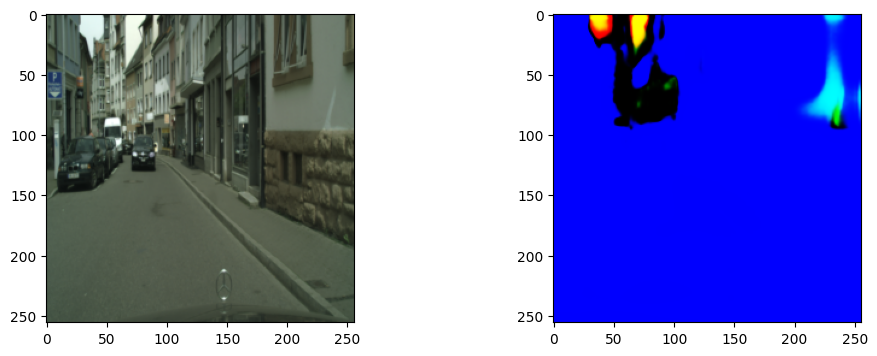

In [ ]:
real,_ = next(iter(train_loader))
real = real.to(device)

with torch.no_grad():
    # encoded_vector = enc(real)
    # reconstruction = gen(encoded_vector)
    # final_reconstruciton, rec, seg, rec_logits, seg_logits = generate_image(real)
    final_reconstruciton = generate_image(real)


print(real.max(), real.min(), real.mean())
print(final_reconstruciton.max(), final_reconstruciton.min(), final_reconstruciton.mean())
real = scale_for_display(real)

final_reconstruciton = scale_for_display(final_reconstruciton)
fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].imshow(real[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(final_reconstruciton[0].permute(1,2,0).cpu().numpy())


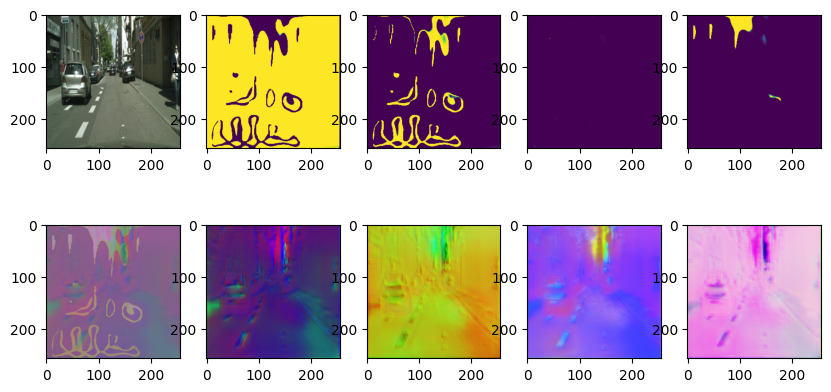

In [ ]:
# real,_ = next(iter(train_loader))
# real = real.to(device)

# with torch.no_grad():
#     # encoded_vector = enc(real)
#     # reconstruction = gen(encoded_vector)
#     final_reconstruciton, rec, seg, rec_logits, seg_logits = generate_image(real)

# real = scale_for_display(real)
# final_reconstruciton = scale_for_display(final_reconstruciton)


# n_of_components = seg.shape[1]
# fig,ax = plt.subplots(2,n_of_components+1,figsize=(10,5))
# ax[0,0].imshow(real[0].cpu().permute(1,2,0).numpy())
# ax[1,0].imshow(final_reconstruciton[0].cpu().permute(1,2,0).numpy())

# for i in range(n_of_components):
#     ax[0,i+1].imshow(seg[0,i].cpu().numpy())
#     scaled_img = scale_for_display(rec[:,i])
#     ax[1,i+1].imshow(scaled_img[0].cpu().permute(1,2,0).numpy())